In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from magpylib import magnet
from magpylib_material_response import demag, meshing

In [3]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 16,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)

labels = ["Component", "Euler", "Quaternion"]
colors_ = ["#784c99", "#6780be", "#e93ea5"]
markers = ["v", "o", "*"]

In [4]:
cuboid = magnet.Cuboid(dimension=(1, 1, 0.1), polarization=(0, 1, 0))
mesh = meshing.mesh_Cuboid(cuboid=cuboid, target_elems=(40, 40, 1))

cells = np.array([c.position for c in mesh])
M_hom = mesh.getM(cells)
M_hom_norm = np.linalg.norm(M_hom, axis=1)
M_hom_normalized = M_hom / np.expand_dims(M_hom_norm, 0).T

demag.apply_demag(mesh, susceptibility=10, inplace=True)
M = mesh.getM(cells)
M_norm = np.linalg.norm(M, axis=1)
M_normalized = M / np.expand_dims(M_norm, 0).T


2025-08-07 at 10:45:19 |   INFO   | run | {} ℹ️ Start Demagnetization tensor calculation
2025-08-07 at 10:45:19 |   INFO   | run | {} ℹ️ Start Demagnetization (inplace) of Collection(id=5576542496) with 1600 cells - Counter({'Cuboid': 1600})
2025-08-07 at 10:45:19 |   INFO   | run | {} ℹ️ Start getH with unit_pol=(1, 0, 0)
2025-08-07 at 10:45:20 | SUCCESS  | timelog | {} ✅  getH with unit_pol=(1, 0, 0) done 🕑 1.469sec
2025-08-07 at 10:45:21 |   INFO   | run | {} ℹ️ Start getH with unit_pol=(0, 1, 0)
2025-08-07 at 10:45:22 | SUCCESS  | timelog | {} ✅  getH with unit_pol=(0, 1, 0) done 🕑 1.496sec
2025-08-07 at 10:45:23 |   INFO   | run | {} ℹ️ Start getH with unit_pol=(0, 0, 1)
2025-08-07 at 10:45:23 | SUCCESS  | timelog | {} ✅  getH with unit_pol=(0, 0, 1) done 🕑 1.479sec
2025-08-07 at 10:45:23 | SUCCESS  | timelog | {} ✅  Demagnetization tensor calculation done 🕑 5.001sec
2025-08-07 at 10:45:25 | SUCCESS  | timelog | {} ✅  Demagnetization (inplace) of Collection(id=5576542496) with 160

In [12]:
tt = np.linspace(-0.4, 0.4, 6)

quiver_grid = np.array([(x, y, 0) for x in tt for y in tt])

Mq_hom = cuboid.getM(quiver_grid)
Mq_hom_norm = np.linalg.norm(Mq_hom, axis=1)
Mq_hom_normalized = Mq_hom / np.expand_dims(Mq_hom_norm, 0).T

Mq = mesh.getM(quiver_grid)
Mq_norm = np.linalg.norm(Mq, axis=1)
Mq_normalized = Mq / np.expand_dims(Mq_norm, 0).T


In [13]:
M_hom_norm

array([795774.71502628, 795774.71502628, 795774.71502628, ...,
       795774.71502628, 795774.71502628, 795774.71502628])

In [14]:
M_ratio = M_norm / M_hom_norm

In [15]:
M_unit = np.ones_like(M_ratio)

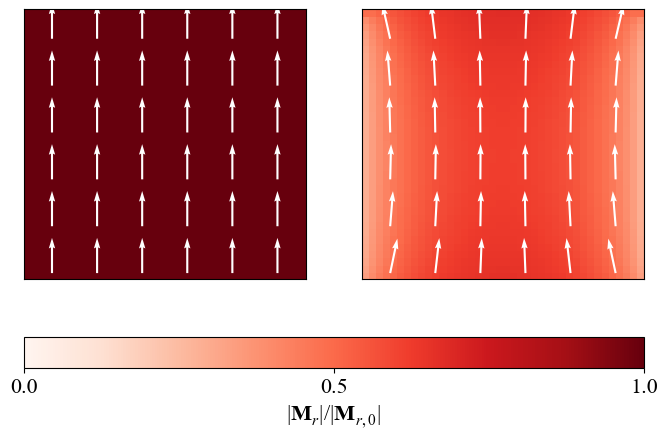

In [27]:
from matplotlib.axes import Axes

ax: list[Axes]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Plot quiver and scalar field

vmin, vmax = 0, 1
cmap = "Reds"
qcolor = "white"

# Plot scalar field and get the mappable for colorbar
pc1 = ax[0].pcolormesh(
    *np.meshgrid(np.unique(cells[:, 0]), np.unique(cells[:, 1])),
    M_unit.reshape(len(np.unique(cells[:, 1])), len(np.unique(cells[:, 0]))),
    cmap=cmap,
    vmin=vmin,
    vmax=vmax
)

pc2 = ax[1].pcolormesh(
    *np.meshgrid(np.unique(cells[:, 0]), np.unique(cells[:, 1])),
    M_ratio.reshape(len(np.unique(cells[:, 1])), len(np.unique(cells[:, 0]))),
    cmap=cmap,
    vmin=vmin,
    vmax=vmax
)

q0 = ax[0].quiver(
    quiver_grid[:, 0],
    quiver_grid[:, 1],
    Mq_hom_normalized[:, 0],
    Mq_hom_normalized[:, 1],
    scale=8,
    color=qcolor,
    linewidth=10,  # Increase arrow thickness
)
q1 = ax[1].quiver(
    quiver_grid[:, 0],
    quiver_grid[:, 1],
    Mq_normalized[:, 0],
    Mq_normalized[:, 1],
    scale=8,
    color=qcolor,
    linewidth=10,  # Increase arrow thickness
)

for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_ylim((-0.42, 0.5))

cbar = fig.colorbar(pc1, ax=ax, location="bottom")
cbar.set_ticks([0, 0.5, 1])
cbar.set_label(label=r"$|\mathbf{M}_{r}|/|\mathbf{M}_{r, 0}|$")
plt.savefig("magnetization_transparent.png", format="png", transparent=True)